In [1]:
# !pip install pandas numpy matplotlib seaborn nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
import nltk


In [2]:
berts=pd.read_csv(r'D:\ProjectExhibition1\ProjectExb\Corona.csv')

In [3]:

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Define a function to clean text
def clean_text(text):
    try:
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Remove mentions and hashtags
        text = re.sub(r'@\w+|#\w+', '', text)
        # Remove special characters and numbers
        text = re.sub(r'[^A-Za-z\s]', '', text)
        # Lowercase the text
        text = text.lower()
        # Tokenize the text
        tokens = word_tokenize(text)
        # Remove stop words
        tokens = [word for word in tokens if word not in stopwords.words('english')]
        # Lemmatize the tokens
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        # Join the tokens back into a single string
        cleaned_text = ' '.join(tokens)
        return cleaned_text
    except Exception as e:
        print(f"Error processing text: {text}\n{e}")
        return ''


# Apply the cleaning function to the 'text' column
berts['cleaned_text'] = berts['text'].apply(clean_text)

# Display the cleaned DataFrame
print(berts.head())


   id                                               text  \
0   1  @YuhuaWang5 If any one want to study how both ...   
1   2  @narendramodi @PMOIndia  - Are there any chanc...   
2   3  @Out5p0ken @racc1964 @WhiteHouse @realDonaldTr...   
3   4  why is there no bread left in any supermarket?...   
4   5  @MudiwaHood is this a joke or you mean it?Mayb...   

                                        cleaned_text  
0  one want study communist propaganda china viru...  
1  chance create covid relief fund india many hap...  
2  fairness probably cant pronounce corona virus ...  
3   bread left supermarket lot eat bread corona came  
4  joke mean itmaybe start asking mothercousins a...  


In [ ]:
# !pip install torch transformers
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline

import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Assuming berts is your DataFrame containing the text data
texts = berts['cleaned_text'].tolist()

# Load pre-trained BERT model and tokenizer
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"  # Pre-trained sentiment model
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Create a pipeline for sentiment analysis
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# Map star ratings to descriptive sentiment labels
def map_sentiment(star_rating):
    if star_rating == '1 star':
        return 'Very negative sentiment'
    elif star_rating == '2 stars':
        return 'Negative sentiment'
    elif star_rating == '3 stars':
        return 'Neutral sentiment'
    elif star_rating == '4 stars':
        return 'Positive sentiment'
    elif star_rating == '5 stars':
        return 'Very positive sentiment'

# Perform sentiment analysis
tqdm.pandas(desc="Analyzing Sentiment with BERT")
berts['bert_sentiment'] = berts['cleaned_text'].progress_apply(lambda text: sentiment_pipeline(text)[0]['label'])

# Apply the mapping to the sentiment labels
berts['bert_sentiment'] = berts['bert_sentiment'].apply(map_sentiment)

# Display results
print(berts[['cleaned_text', 'bert_sentiment']].head())

# Count sentiment categories
sentiment_counts = berts['bert_sentiment'].value_counts()

# Define color scheme based on sentiment labels
sentiment_colors = {
    'Very negative sentiment': 'darkred',
    'Negative sentiment': 'red',
    'Neutral sentiment': 'yellow',
    'Positive sentiment': 'lightgreen',
    'Very positive sentiment': 'darkgreen'
}



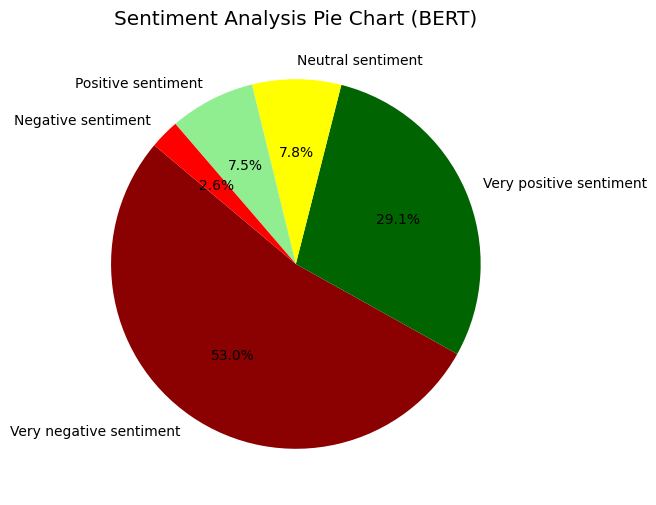

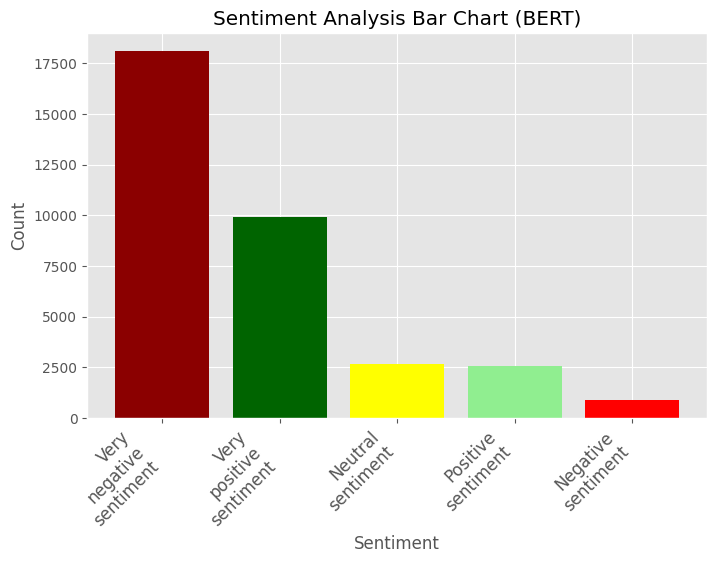

In [15]:
import matplotlib.pyplot as plt
import textwrap

# Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=[sentiment_colors[label] for label in sentiment_counts.index]
)
plt.title('Sentiment Analysis Pie Chart (BERT)')
plt.show()

# Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=[sentiment_colors[label] for label in sentiment_counts.index]
)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Analysis Bar Chart (BERT)')

# Wrap text at 10 characters for x-axis labels
wrapped_labels = [textwrap.fill(label, 10) for label in sentiment_counts.index]
plt.xticks(sentiment_counts.index, wrapped_labels, fontsize=12, rotation=45, ha='right')

plt.show()
